# Activity 2: Analyzing Different Scenarios and Generating the Appropriate Visualization

We'll be working with the 120 years of Olympic History dataset acquired by Randi Griffin from https://www.sports-reference.com/ and made available on the GitHub repository of this book. Your assignment is to identify the top five sports based on the largest number of medals awarded in the year 2016, and then perform the following analysis:

1.  Generate a plot indicating the number of medals awarded in each of the top five sports in 2016.
2.  Plot a graph depicting the distribution of the age of medal winners in the top five sports in 2016.
3.  Find out which national teams won the largest number of medals in the top five sports in 2016.
4.  Observe the trend in the average weight of male and female athletes winning in the top five sports in 2016.

## High-Level Steps

1.  Download the dataset and format it as a pandas DataFrame.
2.  Filter the DataFrame to only include the rows corresponding to medal winners from 2016.
3.  Find out the medals awarded in 2016 for each sport.
4.  List the top five sports based on the largest number of medals awarded. Filter the DataFrame one more time to only include the records for the top five sports in 2016.
5.  Generate a bar plot of record counts corresponding to each of the top five sports.
6.  Generate a histogram for the Age feature of all medal winners in the top five sports (2016).
7.  Generate a bar plot indicating how many medals were won by each country's team in the top five sports in 2016.
8.  Generate a bar plot indicating the average weight of players, categorized based on gender, winning in the top five sports in 2016.

In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Step 1: Download and Load the Dataset

In [3]:
# Load the Olympic dataset from local file
df = pd.read_csv("athlete_events.csv")

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (271116, 15)

Columns: ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## Step 2: Filter for Medal Winners in 2016

In [4]:
# Filter for medal winners in 2016
medals_2016 = df[(df['Year'] == 2016) & (df['Medal'].notna())]

print(f"Total medal records in 2016: {len(medals_2016)}")
print(f"\nMedal distribution:")
print(medals_2016['Medal'].value_counts())

Total medal records in 2016: 2023

Medal distribution:
Medal
Bronze    703
Gold      665
Silver    655
Name: count, dtype: int64


## Step 3 & 4: Find Top 5 Sports by Medal Count in 2016

In [5]:
# Find medals awarded per sport in 2016
medals_per_sport = medals_2016['Sport'].value_counts()
print("Medals per sport in 2016:")
print(medals_per_sport.head(10))

# Get top 5 sports
top_5_sports = medals_per_sport.head(5).index.tolist()
print(f"\nTop 5 Sports: {top_5_sports}")

# Filter for top 5 sports only
top_5_medals = medals_2016[medals_2016['Sport'].isin(top_5_sports)]
print(f"\nTotal medal records in top 5 sports: {len(top_5_medals)}")

Medals per sport in 2016:
Sport
Athletics       192
Swimming        191
Rowing          144
Football        106
Hockey           99
Handball         89
Cycling          84
Canoeing         82
Water Polo       78
Rugby Sevens     74
Name: count, dtype: int64

Top 5 Sports: ['Athletics', 'Swimming', 'Rowing', 'Football', 'Hockey']

Total medal records in top 5 sports: 732


## Step 5: Bar Plot of Medal Counts for Top 5 Sports (2016)

Generate a bar plot of record counts corresponding to each of the top five sports.

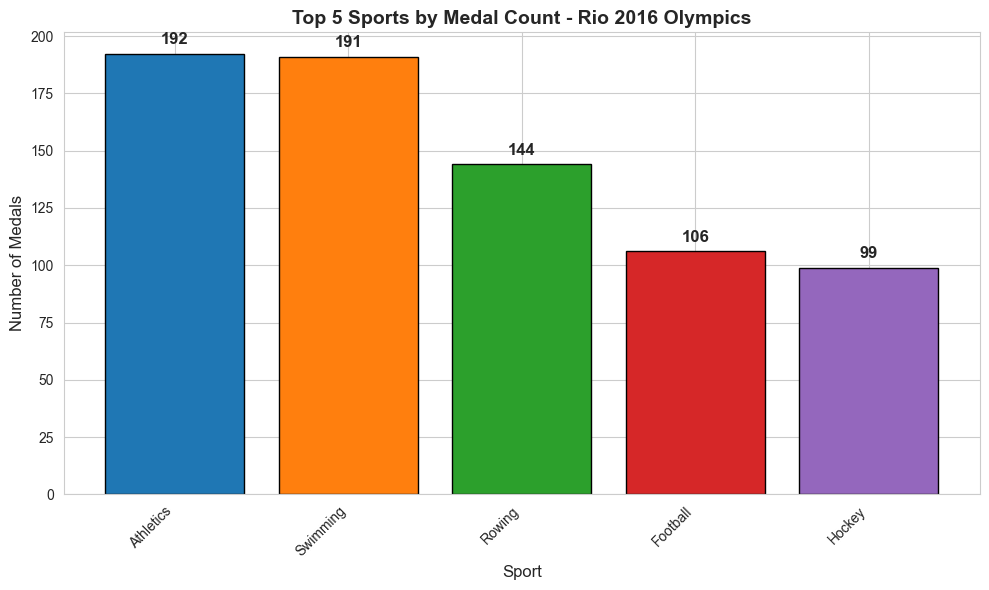

In [6]:
# Bar plot of medal counts for top 5 sports
top_5_counts = medals_per_sport.head(5)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = ax.bar(top_5_counts.index, top_5_counts.values, color=colors, edgecolor='black')

# Add value labels on bars
for bar, value in zip(bars, top_5_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
            str(value), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Sport', fontsize=12)
ax.set_ylabel('Number of Medals', fontsize=12)
ax.set_title('Top 5 Sports by Medal Count - Rio 2016 Olympics', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 6: Age Distribution of Medal Winners in Top 5 Sports (2016)

Generate a histogram for the Age feature of all medal winners in the top five sports.

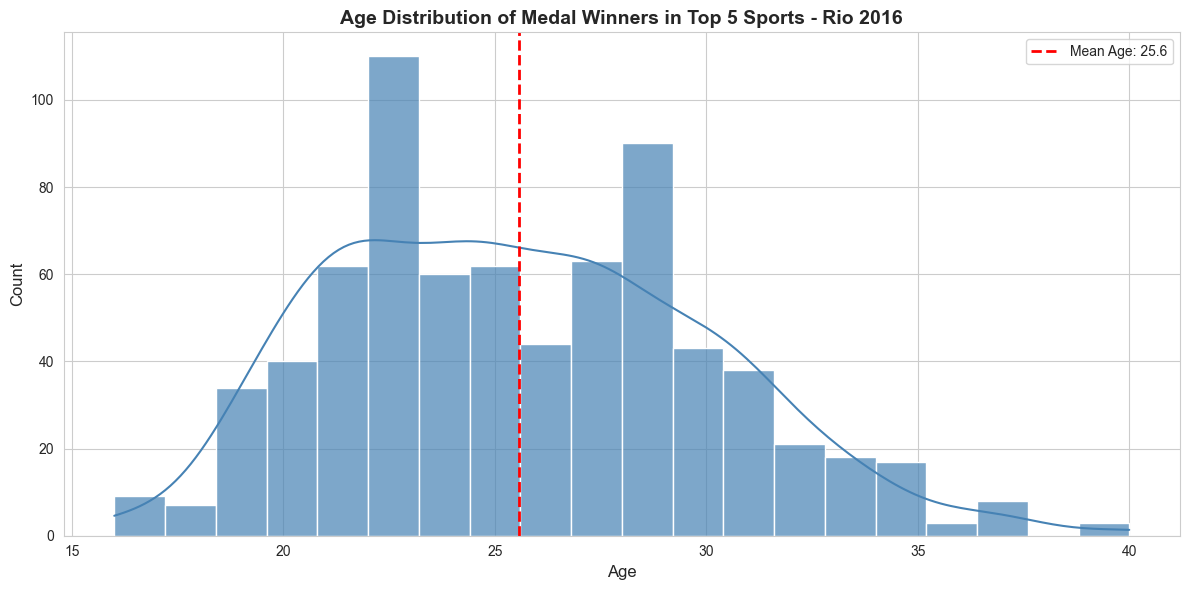


Age Statistics:
count    732.000000
mean      25.577869
std        4.451373
min       16.000000
25%       22.000000
50%       25.000000
75%       29.000000
max       40.000000
Name: Age, dtype: float64


In [7]:
# Histogram of age distribution for medal winners in top 5 sports
fig, ax = plt.subplots(figsize=(12, 6))

# Overall histogram
sns.histplot(data=top_5_medals, x='Age', bins=20, kde=True, color='steelblue', alpha=0.7, ax=ax)

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Age Distribution of Medal Winners in Top 5 Sports - Rio 2016', fontsize=14, fontweight='bold')
ax.axvline(top_5_medals['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean Age: {top_5_medals['Age'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nAge Statistics:")
print(top_5_medals['Age'].describe())

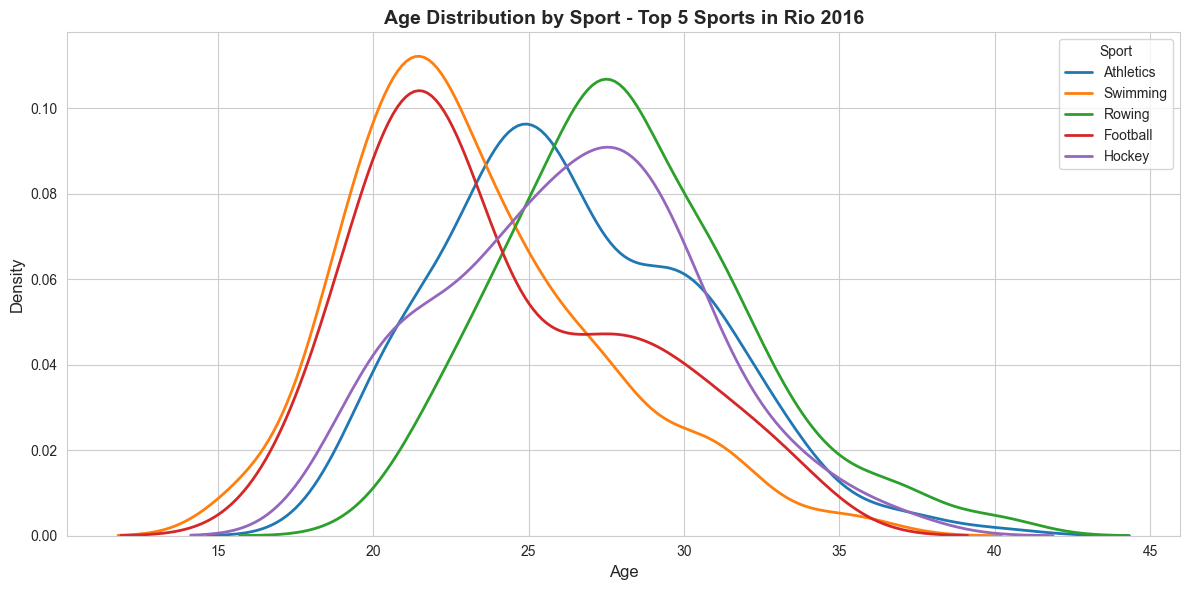

In [8]:
# Age distribution by sport (stacked histogram)
fig, ax = plt.subplots(figsize=(12, 6))

for sport in top_5_sports:
    sport_data = top_5_medals[top_5_medals['Sport'] == sport]['Age'].dropna()
    sns.kdeplot(data=sport_data, label=sport, linewidth=2, ax=ax)

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Age Distribution by Sport - Top 5 Sports in Rio 2016', fontsize=14, fontweight='bold')
ax.legend(title='Sport')
plt.tight_layout()
plt.show()

## Step 7: Medals by Country in Top 5 Sports (2016)

Find out which national teams won the largest number of medals in the top five sports.

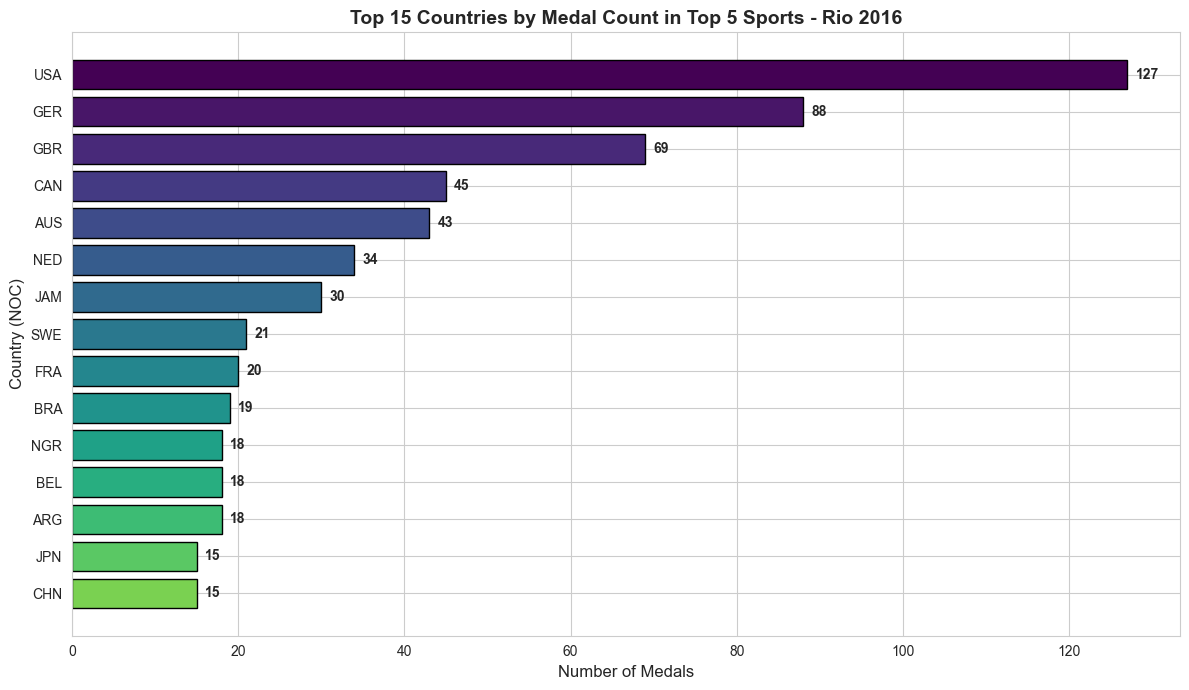

In [9]:
# Medals by country in top 5 sports
medals_by_country = top_5_medals['NOC'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0, 0.8, len(medals_by_country)))
bars = ax.barh(medals_by_country.index[::-1], medals_by_country.values[::-1], color=colors[::-1], edgecolor='black')

# Add value labels
for bar, value in zip(bars, medals_by_country.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            str(value), ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Medals', fontsize=12)
ax.set_ylabel('Country (NOC)', fontsize=12)
ax.set_title('Top 15 Countries by Medal Count in Top 5 Sports - Rio 2016', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: Average Weight by Gender in Top 5 Sports (2016)

Observe the trend in the average weight of male and female athletes winning in the top five sports.

Average Weight (kg) by Sport and Gender:
Sex           F     M
Sport                
Athletics  62.6  79.1
Football   63.0  75.7
Hockey     63.1  78.4
Rowing     71.8  88.8
Swimming   66.2  83.4


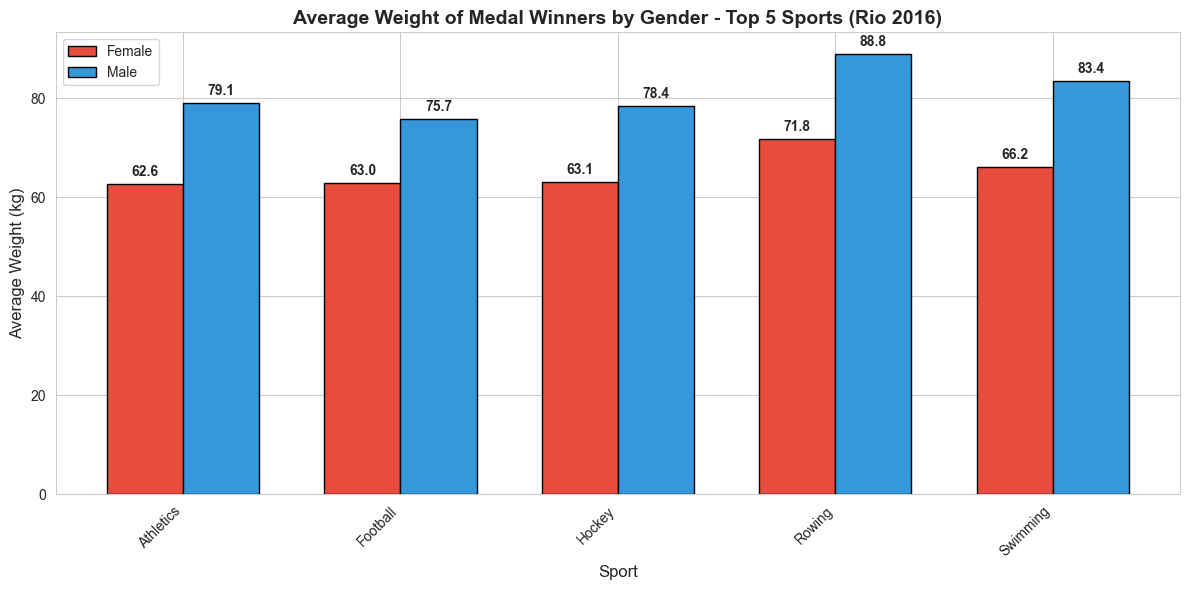

In [10]:
# Calculate average weight by sport and gender
avg_weight = top_5_medals.groupby(['Sport', 'Sex'])['Weight'].mean().unstack()
print("Average Weight (kg) by Sport and Gender:")
print(avg_weight.round(1))

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(avg_weight.index))
width = 0.35

bars_f = ax.bar(x - width/2, avg_weight['F'], width, label='Female', color='#e74c3c', edgecolor='black')
bars_m = ax.bar(x + width/2, avg_weight['M'], width, label='Male', color='#3498db', edgecolor='black')

# Add value labels
for bar in bars_f:
    height = bar.get_height()
    if not np.isnan(height):
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars_m:
    height = bar.get_height()
    if not np.isnan(height):
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Sport', fontsize=12)
ax.set_ylabel('Average Weight (kg)', fontsize=12)
ax.set_title('Average Weight of Medal Winners by Gender - Top 5 Sports (Rio 2016)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(avg_weight.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Bonus: Interactive Visualizations with Plotly

In [11]:
# Interactive bar chart - Medals by sport with medal type breakdown
medal_breakdown = top_5_medals.groupby(['Sport', 'Medal']).size().reset_index(name='Count')

fig = px.bar(medal_breakdown, 
             x='Sport', 
             y='Count', 
             color='Medal',
             color_discrete_map={'Gold': '#FFD700', 'Silver': '#C0C0C0', 'Bronze': '#CD7F32'},
             title='Medal Distribution by Sport - Top 5 Sports (Rio 2016)',
             labels={'Count': 'Number of Medals'},
             barmode='group')

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [12]:
# Interactive sunburst chart - Country > Sport > Medal
fig = px.sunburst(top_5_medals, 
                  path=['NOC', 'Sport', 'Medal'], 
                  title='Medal Distribution: Country → Sport → Medal Type (Rio 2016)',
                  color='Medal',
                  color_discrete_map={'Gold': '#FFD700', 'Silver': '#C0C0C0', 'Bronze': '#CD7F32'})
fig.show()

## Conclusion

### Key Findings from Rio 2016 Olympics Analysis:

1. **Top 5 Sports by Medal Count:**
   - Athletics (192 medals) and Swimming (191 medals) dominate
   - Followed by Rowing (144), Football (106), and Hockey (99)

2. **Age Distribution:**
   - Mean age of medal winners: ~25.6 years
   - Swimming athletes tend to be younger (peak ~21 years)
   - Rowing athletes tend to be older (peak ~27 years)

3. **Country Performance:**
   - USA dominates with 127 medals in top 5 sports
   - Germany (88) and Great Britain (69) follow
   - Jamaica excels despite being a small country (30 medals, mainly Athletics)

4. **Weight by Gender:**
   - Rowing athletes are heaviest (M: 88.8 kg, F: 71.8 kg)
   - Football players are lightest among males (75.7 kg)
   - Clear gender differences across all sports (~15-17 kg difference)